# Case Study: Israel-Palestine on YouTube

The following case study was used for validation purposes for a larger project on _narrative polarisation_ ([Elfes et al., 2026](https://doi.org/10.48550/arXiv.2601.07398)). We describe the process of [deriving](#open-annotation), [applying](#closed-annotation), and [testing](#comparing-annotations) a closed label set.

We test the applicability of this framework on a corpus of social media comments addressing the Israeli–Palestinian conflict. Their short, often ambiguous, and context-dependent nature makes comments a challenging test case. Diverging narratives are fundamental to polarisation processes, and tracking their development at scale is essential for understanding how polarisation unfolds online.

Although open annotation (i.e., without a predefined label set) produces accurate labels, it is difficult to generalise consistently, as labels will vary in phrasing and level of granularity. For example, one comment might be annotated with `Palestinian civilians` desiring `protection from air raids` and another with `Palestinians` desiring `security`. Both effectively refer to the same core narrative assumptions, but the labels are difficult to match post hoc. A predefined label set is therefore essential, especially when testing inter-rater reliability.

To prevent divergent interpretations, the final label set needs to be comprehensive while avoiding excessive overlap. For this case study, we compiled a label set comprising 21 actors and 7 objects; the Object category received its own distinct label set due to its pivotal and unique role. The labels were derived through a three-step process:
1. An initial pilot set of 11K samples was labelled freely by the LLM.
2. We distilled a concise list of actors from this pool by standardising spelling, grouping individual actors under broader categories, and removing rare actors.
3. This list was refined through deliberation with human annotators, addressing gaps in LLM-generated labels and reducing overlap.

For a more in-depth explanation of the framework and analysis of the case study see Elfes and Bastos (under review).


**References**

Elfes, J., & Bastos, M. (under review). A Structuralist Framework for Computational Narrative Analysis.

Elfes, J., Bastos, M., & Aiello, L. M. (2026). On Narrative: The Rhetorical Mechanisms of Online Polarisation (arXiv:2601.07398). arXiv. https://doi.org/10.48550/arXiv.2601.07398

In [13]:
import yaml
import pandas as pd
import seaborn as sns

from actantial import load_annotations, compare_annotations
from matplotlib import pyplot as plt
from actantial.config import ACTANTS

ACTOR_ACTANTS = [a for a in ACTANTS if a!="Object"]

### Open annotation

Here, we demonstrate the open annotation of 330 test comments, the labels from which are then used to synthesise a more concise label set. This section is for illustration only, deriving an actual label set requires more data, and that data should not overlap with the test set, so as not to compromise the validation process.

We first annotate the data openly using a quantised version of DeepSeek, run on a local GPU.

```bash
actantial \
    --data_file "data/sample_youtube_comments.csv" \
    --output_dir "output" \
    --backend huggingface \
    --repository "deepseek-ai" \
    --model "DeepSeek-R1-Distill-Qwen-32B" \
    --template "prompt_open" \
    --quantise
```

In [14]:
# load data
open_annotations = pd.read_csv("data/sample_youtube_comments.csv")

# load llm annotations
open_annotations = load_annotations(
    open_annotations, 
    label_folder="output/actantial_models/DeepSeek-R1-Distill-Qwen-32B/prompt_open/20260529_161446",
)

open_annotations[ACTANTS].head()


,Subject,Object,Sender,Receiver,Helper,Opponent
0,zionist movement,zionist goals,zionist leadership,state of israel,supportive nations,palestine and her people
1,israeli fighting men,ability to fight effectively,usa and europe,israel,None,the speaker
2,hamas,terrorize and kill those who disbelieve,koran,israel,i,the innocent (the ones who refuse to obey that...
3,the speaker,banning and punishing the perpetrators,authority/government,perpetrators,apple,israel
4,eu human rights monitor,speaking about the attack,entire world,eu human rights monitor,None,hamas


In [15]:
actor_counts = pd.Series(open_annotations[ACTOR_ACTANTS].values.flatten()).value_counts()
object_counts = pd.Series(open_annotations['Object'].values.flatten()).value_counts()


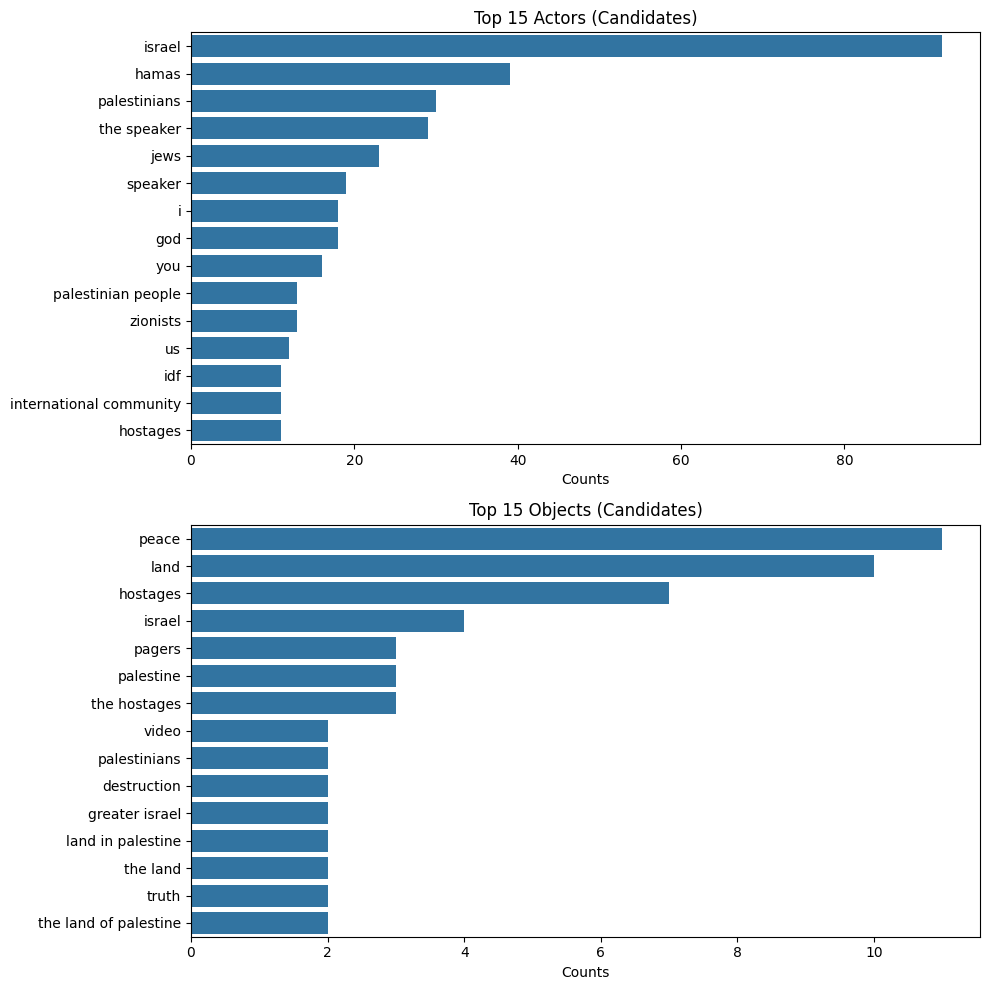

In [16]:
n=15

fig, axes = plt.subplots(2, 1, figsize=(10, 10))

sns.barplot(x=actor_counts.head(n).values, y=actor_counts.head(n).index, ax=axes[0])
sns.barplot(x=object_counts.head(n).values, y=object_counts.head(n).index, ax=axes[1])


axes[0].set_title(f'Top {n} Actors (Candidates)')
axes[0].set_xlabel('Counts')
axes[0].set_ylabel('')

axes[1].set_title(f'Top {n} Objects (Candidates)')
axes[1].set_xlabel('Counts')
axes[1].set_ylabel('')

plt.tight_layout()

Below, we illustrate some potential ways open labels could be reflected in a closed label set. We can summarise the actors by grouping different phrasings of the same actor (e.g., `palestinian people` → `palestinians`) and subsuming specific actors under broader labels (e.g., `idf` → `israel`). Notably, collapsing labels involves significant conceptual decisions about the desired granularity of the final label set. 

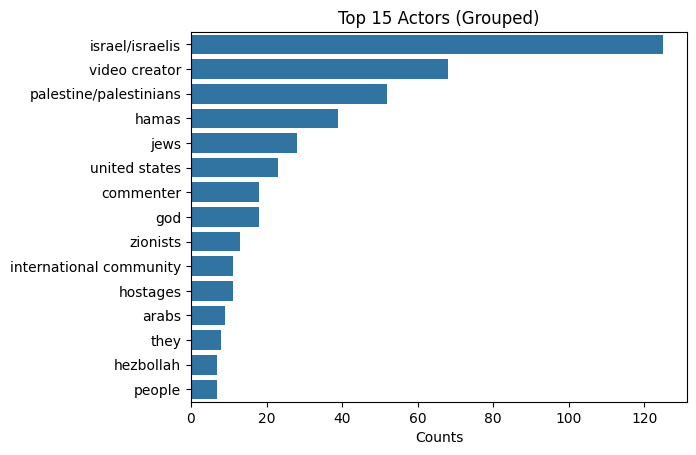

In [17]:
actor_mapping = {
    "the speaker": "video creator",
    "speaker": "video creator",
    "you": "video creator",
    "i": "commenter",
    "palestinian people": "palestine/palestinians",
    "palestinians": "palestine/palestinians",
    "palestine": "palestine/palestinians",
    "israelis": "israel/israelis",
    "israel": "israel/israelis",
    "idf": "israel/israelis",
    "netanyahu": "israel/israelis",
    "mossad": "israel/israelis",
    "us government": "united states",
    "us": "united states",
    "aipac": "united states",
    "jewish people": "jews",
}

# map and aggregate actor counts
actor_counts_mapped = actor_counts.rename(index=actor_mapping).groupby(level=0).sum().sort_values(ascending=False)

n= 15
sns.barplot(x=actor_counts_mapped.head(n).values, y=actor_counts_mapped.head(n).index)
plt.title(f'Top {n} Actors (Grouped)')
plt.xlabel("Counts")
plt.ylabel("")
plt.show()


### Closed annotation
The final set of 21 actors and 7 objects was derived through exploratory analysis, as illustrated above, and refined through several rounds of annotation and discussion with human annotators.

In [26]:
# load closed label sets
with open("data/sample_actors.yaml", "r") as f:
    actor_labels = yaml.safe_load(f)

with open("data/sample_objects.yaml", "r") as f:
    object_labels = yaml.safe_load(f)

print("Actor Labels:")
print(actor_labels)    
print("\nObject Labels:")
print(object_labels)

Actor Labels:
['audience/commenter', 'both sides', 'britain', 'egypt', 'extremists', 'god/allah', 'hamas', 'india', 'idf', 'iran', 'israel/israelis', 'jews', 'muslims', 'palestine/palestinians', 'united nations', 'united states', 'video creator', 'west', 'world', 'zionists']

Object Labels:
['information', 'peace', 'power', 'rights/freedoms', 'security/safety', 'territory', 'violence']


#### LLM

```bash
actantial \
    --data_file "data/sample_youtube_comments.csv" \
    --output_dir "output" \
    --backend huggingface \
    --repository "deepseek-ai" \
    --model "DeepSeek-R1-Distill-Qwen-32B" \
    --template "prompt_closed" \
    --actor_labels_path "data/sample_actors.yaml" \
    --object_labels_path "data/sample_objects.yaml" \
    --quantise
```

#### Humans
Two human coders annotated the data following a detailed [codebook](https://osf.io/qbaeg/files/59k6c).

### Comparing annotations

In [28]:
# load llm annotations with closed label set
annotations_llm = pd.read_csv("data/sample_youtube_comments.csv")

# the LLM does not always adhere to the label set;
# passing label paths automatically filters out unknown labels
# timestamp corresponds to the annotations provided with this example
annotations_llm = load_annotations(
    annotations_llm, 
    label_folder="output/actantial_models/DeepSeek-R1-Distill-Qwen-32B/prompt_closed/20260529_163023",
    actor_labels_path="data/sample_actors.yaml",
    object_labels_path="data/sample_objects.yaml",
)

annotations_llm[ACTANTS].head()


Dropped 5/310 unknown actors for actant 'Subject'
Dropped 1/330 unknown actors for actant 'Object'
Dropped 9/208 unknown actors for actant 'Sender'
Dropped 6/213 unknown actors for actant 'Receiver'
Dropped 8/47 unknown actors for actant 'Helper'
Dropped 4/159 unknown actors for actant 'Opponent'


,Subject,Object,Sender,Receiver,Helper,Opponent
0,audience/commenter,information,zionists,audience/commenter,None,None
1,israel/israelis,power,None,None,None,None
2,hamas,violence,god/allah,hamas,None,israel/israelis
3,israel/israelis,violence,israel/israelis,audience/commenter,None,None
4,hamas,violence,united nations,world,None,united nations


In [8]:
# load human annotations
annotator1 = pd.read_csv("data/sample_youtube_annotator1.csv")
annotator2 = pd.read_csv("data/sample_youtube_annotator2.csv")

annotator1[ACTANTS].head()


,Subject,Object,Sender,Receiver,Helper,Opponent
0,audience/commenter,information,audience/commenter,NaN,NaN,NaN
1,israel/israelis,violence,NaN,NaN,NaN,israel/israelis
2,hamas,violence,hamas,israel/israelis,NaN,israel/israelis
3,NaN,security/safety,NaN,NaN,NaN,NaN
4,hamas,violence,hamas,israel/israelis,NaN,NaN


#### IRR
We can easily calculate inter-rater reliability (IRR) scores using the `compare_annotations` function.

In [11]:
compare_annotations(
    [annotator1, annotator2, annotations_llm],
    names=["a1", "a2", "llm"],
    metric='krippendorff_alpha', 
).round(2)

,alpha,N
Subject,0.51,648
Object,0.51,752
Sender,0.58,126
Receiver,0.58,106
Helper,0.56,19
Opponent,0.61,136
avg,0.56,<NA>


The left column shows Krippendorff's alpha across all three annotators, and the right reports the number of non-NA pairs between each combination of annotators. We can see that the Helper is annotated in very few cases with only 19 pairs where two annotators both provided a label. Moreover, the average alpha of $0.56$ lies significantly below the commonly assumed threshold of $0.67$. This is partly due to poor performance on rare edge classes in the label set. We can use `f1_micro` for a comparison that weights all labels equally and focuses simply on the number of matching labels (same as accuracy).

In [29]:
compare_annotations(
    dfs=[annotator1, annotator2, annotations_llm],
    names=["a1", "a2", "llm"],
    metric='f1_micro',
).round(2)

,a1_a2,a1_llm,a2_llm,avg,N
Subject,0.62,0.67,0.52,0.61,648
Object,0.63,0.66,0.53,0.61,752
Sender,0.93,0.61,0.82,0.79,126
Receiver,0.80,0.65,0.83,0.76,106
Helper,0.75,0.75,0.57,0.69,19
Opponent,0.83,0.61,0.56,0.67,136
avg,0.76,0.66,0.64,0.69,<NA>


Unlike Krippendorff's alpha, F1 scores are calculated pairwise: each combination of two annotators receives one score, and these are averaged across all three pairs. The average can be skewed if one annotator labelled significantly fewer cases than the others.

You can set `verbose=True` to get a better sense of which cases lack annotations and why.

In [12]:
compare_annotations(
    dfs=[annotator1, annotator2, annotations_llm],
    names=["a1", "a2", "llm"],
    metric='f1_micro',
    verbose=True
).round(2)


Dropped 127/330 rows because of missing annotations for actant 'Subject', pair 'a1_a2'
Dropped 108/330 rows because of missing annotations for actant 'Subject', pair 'a1_llm'
Dropped 107/330 rows because of missing annotations for actant 'Subject', pair 'a2_llm'
Dropped 99/330 rows because of missing annotations for actant 'Object', pair 'a1_a2'
Dropped 51/330 rows because of missing annotations for actant 'Object', pair 'a1_llm'
Dropped 88/330 rows because of missing annotations for actant 'Object', pair 'a2_llm'
Dropped 315/330 rows because of missing annotations for actant 'Sender', pair 'a1_a2'
Dropped 236/330 rows because of missing annotations for actant 'Sender', pair 'a1_llm'
Dropped 313/330 rows because of missing annotations for actant 'Sender', pair 'a2_llm'
Dropped 325/330 rows because of missing annotations for actant 'Receiver', pair 'a1_a2'
Dropped 235/330 rows because of missing annotations for actant 'Receiver', pair 'a1_llm'
Dropped 324/330 rows because of missing ann

,a1_a2,a1_llm,a2_llm,avg,N
Subject,0.62,0.67,0.52,0.61,648
Object,0.63,0.66,0.53,0.61,752
Sender,0.93,0.61,0.82,0.79,126
Receiver,0.80,0.65,0.83,0.76,106
Helper,0.75,0.75,0.57,0.69,19
Opponent,0.83,0.61,0.56,0.67,136
avg,0.76,0.66,0.64,0.69,<NA>


Here we can see how many annotation pairs between each combination of two annotators contained at least one NA value. For the Helper, nearly every pair contains an NA, making this score unreliable. We therefore focus on Sender and Receiver in what follows.

In [30]:
compare_annotations(
    dfs=[annotator1, annotator2, annotations_llm],
    names=["a1", "a2", "llm"],
    metric='f1_micro',
    actant_columns=["Sender", "Receiver"],
    verbose=True
).round(2)


Dropped 315/330 rows because of missing annotations for actant 'Sender', pair 'a1_a2'
Dropped 236/330 rows because of missing annotations for actant 'Sender', pair 'a1_llm'
Dropped 313/330 rows because of missing annotations for actant 'Sender', pair 'a2_llm'
Dropped 325/330 rows because of missing annotations for actant 'Receiver', pair 'a1_a2'
Dropped 235/330 rows because of missing annotations for actant 'Receiver', pair 'a1_llm'
Dropped 324/330 rows because of missing annotations for actant 'Receiver', pair 'a2_llm'


,a1_a2,a1_llm,a2_llm,avg,N
Sender,0.93,0.61,0.82,0.79,126
Receiver,0.80,0.65,0.83,0.76,106
avg,0.87,0.63,0.83,0.77,<NA>


We can see that the `a1_llm` pair has around 100 fewer NA pairs than the two pairings involving `a2`. This suggests that `a2` annotated roughly 100 fewer cases for the Sender and Receiver, making the average score for these actants less reliable. We therefore focus on the `a1_llm` scores for these actants.

<i><b><center>Fin</center></b></i>